In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

## WHO HALE data

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [7]:
filename = '../data/who_hale_data.csv'

who_all = pd.read_csv(filename)
who_all.shape

(12936, 9)

In [29]:
who_hale['CountryCode'].value_counts()

CountryCode
COUNTRY                 12210
REGION                    396
WORLDBANKINCOMEGROUP      264
GLOBAL                     66
Name: count, dtype: int64

In [31]:
who_hale = who_all.query('Year >= 2000 and CountryCode == "COUNTRY"').copy()
who_hale['Sex'].value_counts()

Sex
SEX_BTSX    4070
SEX_FMLE    4070
SEX_MLE     4070
Name: count, dtype: int64

In [33]:
# Filter for male and female data
cols = ['Country', 'Year', 'HALE_Years']
male_data = who_hale[who_hale['Sex'] == 'SEX_MLE'][cols].copy()
female_data = who_hale[who_hale['Sex'] == 'SEX_FMLE'][cols].copy()

# Rename the HALE_Years column
male_data = male_data.rename(columns={'HALE_Years': 'HALE_Male'})
female_data = female_data.rename(columns={'HALE_Years': 'HALE_Female'})

# Merge on Country, CountryCode, and Year
hale_by_sex = male_data.merge(
    female_data,
    on=['Country', 'Year']
)

# Optional: Add a gender gap column
hale_by_sex['HALE_Gap'] = hale_by_sex['HALE_Female'] - hale_by_sex['HALE_Male']


In [34]:
hale_by_sex.head()

,Country,Year,HALE_Male,HALE_Female,HALE_Gap
0,AFG,2000,45.943669,46.154851,0.211182
1,AFG,2001,45.989073,46.284875,0.295802
2,AFG,2002,47.407615,46.994510,-0.413105
3,AFG,2003,48.291904,47.702906,-0.588998
4,AFG,2004,48.637754,48.050686,-0.587069


In [35]:
hale_by_sex['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021])

In [36]:
hale_by_sex['Country'].unique()

array(['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT',
       'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS',
       'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA',
       'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG',
       'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI',
       'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH',
       'FIN', 'FJI', 'FRA', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN',
       'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GTM', 'GUY', 'HND', 'HRV',
       'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR',
       'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR',
       'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LKA', 'LSO',
       'LTU', 'LUX', 'LVA', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MKD',
       'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI',
       'MYS', 'NAM', 'NER', 'NGA', 'NIC', 'NLD', 'NOR', 'NPL', 'NZL',
       'OMN', 'PAK',

In [38]:
hale_by_sex['HALE_Male'].isna().sum()

0

In [39]:
hale_by_sex['HALE_Female'].isna().sum()

0

In [59]:
recent = hale_by_sex.query('Year == 2021').set_index('Country')
recent.head()

,Year,HALE_Male,HALE_Female,HALE_Gap
Country,,,,
AFG,2021,49.646948,51.312914,1.665966
AGO,2021,52.803224,54.731134,1.927909
ALB,2021,65.735885,67.758414,2.022528
ARE,2021,67.376838,66.808010,-0.568828
ARG,2021,63.436500,66.150735,2.714235


In [65]:
def scatter_plot(df, title):
    plt.plot(df['HALE_Male'], df['HALE_Female'], '.')
    low, high = 42, 75
    plt.plot([low, high], [low, high], color='gray', alpha=0.5)
    decorate(xlabel='HALE, Male', ylabel='HALE, Female', title=title)

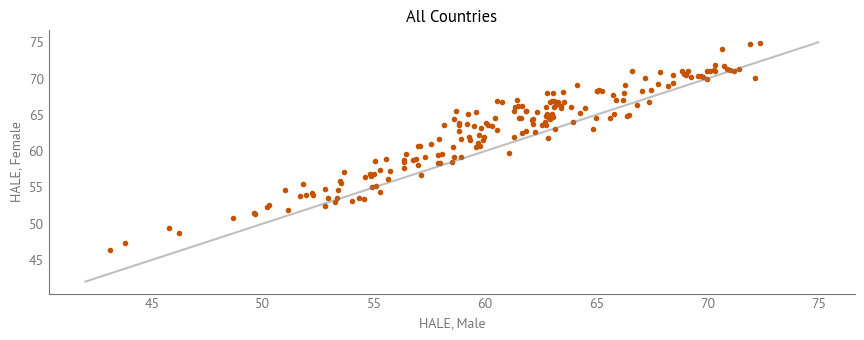

In [66]:
scatter_plot(recent, title='All Countries')

In [61]:
from utils import oecd_codes

df_oecd = recent.loc[oecd_codes]
df_oecd

,Year,HALE_Male,HALE_Female,HALE_Gap
Country,,,,
AUS,2021,70.129739,71.083329,0.953589
AUT,2021,69.052840,70.492301,1.439461
BEL,2021,69.277436,70.274321,0.996885
CAN,2021,68.929934,70.636013,1.706078
CHE,2021,70.909329,71.347458,0.438128
CHL,2021,67.053862,68.273016,1.219154
COL,2021,63.290852,66.819771,3.528919
CRI,2021,66.276979,69.052011,2.775032
CZE,2021,65.046933,68.323581,3.276648


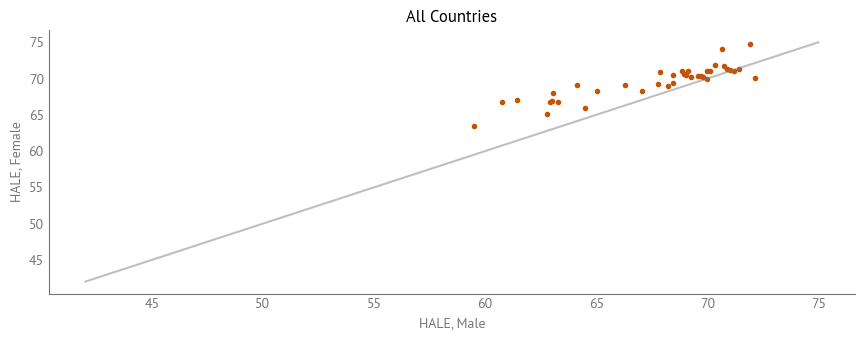

In [67]:
scatter_plot(df_oecd, title='All Countries')

## Our World In Data

https://ourworldindata.org/why-do-women-live-longer-than-men

In [56]:
import requests

filename = '../life-expectancy-of-women-vs-life-expectancy-of-men.csv'

In [57]:
owid = pd.read_csv(filename)
owid.columns = ['Entity', 'Code', 'Year',
       'life_expectancy_female',
       'life_expectancy_male',
       'population',
       'region', 'time', 'time.1']
owid.index = owid['Code']

In [58]:
owid.head()

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1
Code,,,,,,,,,
AFG,Afghanistan,AFG,2023,67.536,64.467,41454709,Asia,2023,2023
ALB,Albania,ALB,2023,81.446,77.728,2811615,Europe,2023,2023
DZA,Algeria,DZA,2023,77.696,74.895,46164169,Africa,2023,2023
ASM,American Samoa,ASM,2023,75.838,70.202,47499,Oceania,2023,2023
AND,Andorra,AND,2023,86.107,82.100,80825,Europe,2023,2023


In [62]:
from utils import save_indicators
save_indicators(df_oecd, 'life_expectancy')

Saved indicators to life_expectancy_indicators.csv


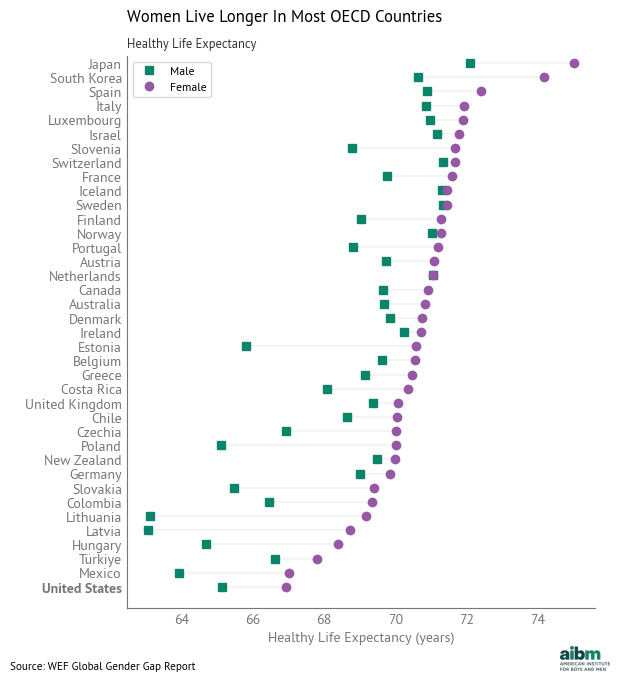

In [63]:
from utils import plot_indicators, add_title

plot_indicators(df_oecd)
plt.xlabel('Healthy Life Expectancy (years)')
add_title("Women Live Longer In Most OECD Countries",
          "Healthy Life Expectancy", y=1.01)

In [64]:
df_oecd['diff'] = df_oecd['female'] - df_oecd['male']
df_oecd.sort_values(by='diff').tail()

,country,page_number,score,rank,male,female,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,diff
code,,,,,,,,,,,,,,,
SVK,Slovakia,319,1.06,1,65.475856,69.406819,1.060037,0.999963,1.06,1.032572,1.06,1.060037,0.999963,121.0,3.930964
EST,Estonia,171,1.06,1,65.801117,70.591652,1.072803,0.987197,1.06,1.011282,1.06,1.072803,0.987197,129.0,4.790534
POL,Poland,299,1.06,1,65.084376,70.014177,1.075745,0.984255,1.06,1.020143,1.06,1.075745,0.984255,130.0,4.929800
LVA,Latvia,233,1.06,1,63.046587,68.738555,1.090282,0.969718,1.06,0.995461,1.06,1.090282,0.969718,139.0,5.691968
LTU,Lithuania,241,1.06,1,63.104683,69.166703,1.096063,0.963937,1.06,0.987179,1.06,1.096063,0.963937,141.0,6.062020


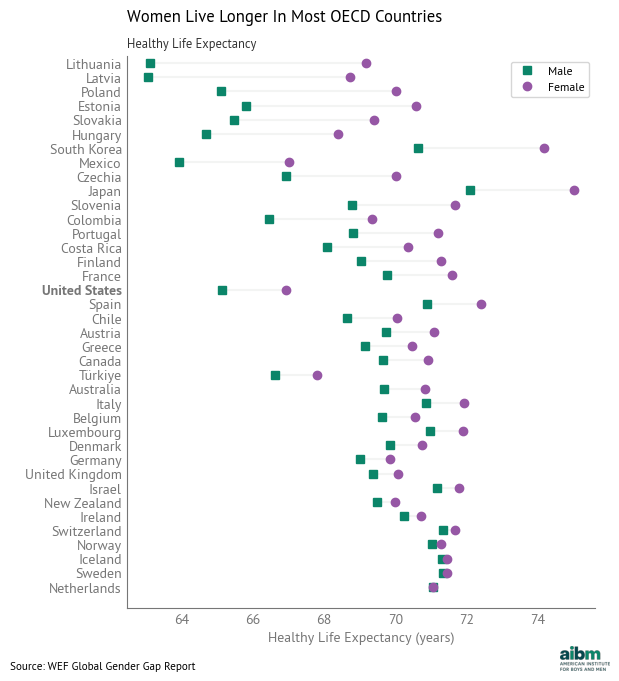

In [65]:
plot_indicators(df_oecd.sort_values(by='diff', ascending=False), sort=False)
plt.xlabel('Healthy Life Expectancy (years)')
add_title("Women Live Longer In Most OECD Countries",
          "Healthy Life Expectancy", y=1.01)

In [66]:
df_oecd.query("country == 'South Korea'")

,country,page_number,score,rank,male,female,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,diff
code,,,,,,,,,,,,,,,
KOR,South Korea,325,1.047,56,70.62433,74.188925,1.050473,1.009527,1.050473,1.046546,1.06,1.050473,1.009527,111.0,3.564595


In [67]:
df_oecd.query("country == 'United States'")

,country,page_number,score,rank,male,female,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,diff
code,,,,,,,,,,,,,,,
USA,United States,361,1.028,91,65.127126,66.927903,1.02765,1.03235,1.02765,1.055145,1.06,1.02765,1.03235,65.0,1.800777


In [68]:
df_oecd.query("country == 'Lithuania'")

,country,page_number,score,rank,male,female,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,diff
code,,,,,,,,,,,,,,,
LTU,Lithuania,241,1.06,1,63.104683,69.166703,1.096063,0.963937,1.06,0.987179,1.06,1.096063,0.963937,141.0,6.06202


In [69]:
df_oecd.query("country == 'Netherlands'")

,country,page_number,score,rank,male,female,who_ratio,who_score,who_score_truncated,owid_score,owid_score_truncated,ratio,revised_score,revised_rank,diff
code,,,,,,,,,,,,,,,
NLD,Netherlands,273,1.002,135,71.052035,71.070623,1.000262,1.059738,1.000262,1.039745,1.039745,1.000262,1.059738,2.0,0.018589


In [70]:
codes = ['NLD', 'LTU', 'USA']
cols = ['country', 'male', 'female', 'ratio', 'score', 'revised_score']
df_oecd.loc[codes, cols].round(3)

,country,male,female,ratio,score,revised_score
code,,,,,,
NLD,Netherlands,71.052,71.071,1.000,1.002,1.060
LTU,Lithuania,63.105,69.167,1.096,1.060,0.964
USA,United States,65.127,66.928,1.028,1.028,1.032


In [71]:
from utils import save_revised_scores
save_revised_scores(df_oecd, 'life_expectancy')

Saved revised scores to life_expectancy_revised_scores.csv


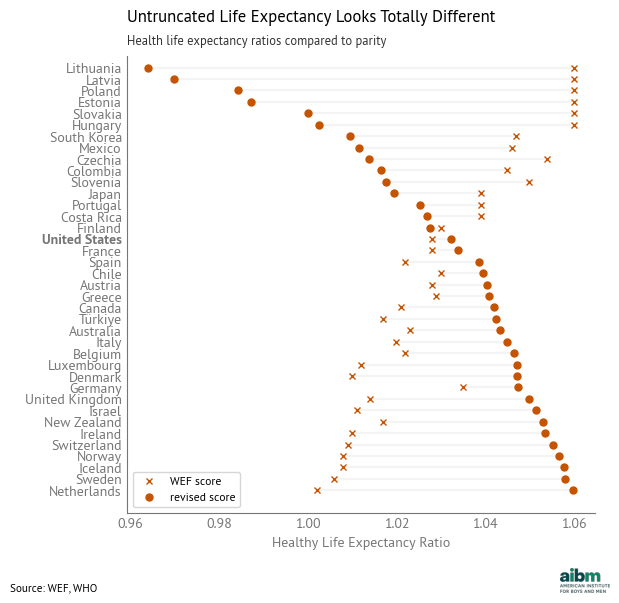

In [72]:
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd)

add_title("Untruncated Life Expectancy Looks Totally Different",
    "Health life expectancy ratios compared to parity", y=1.02
)
decorate(xlabel='Healthy Life Expectancy Ratio')
add_subtext("Source: WEF, WHO", y=-0.05)
logo = add_logo(location=(1.0, -0.05))

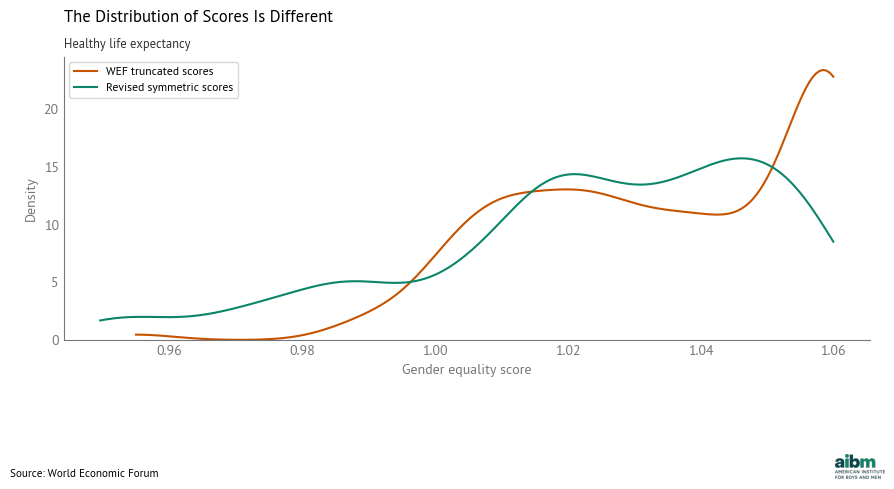

In [73]:
import seaborn as sns

options = dict(cut=0, bw_adjust=0.7)

sns.kdeplot(wef['score'], label='WEF truncated scores', **options)
sns.kdeplot(wef['revised_score'], label='Revised symmetric scores', **options)

decorate(xlabel='Gender equality score')

add_title("The Distribution of Scores Is Different",
          "Healthy life expectancy")
add_subtext("Source: World Economic Forum", y=-0.25)
logo = add_logo(location=(1.0, -0.25))
None